# Task 1 Defense Notebook

Papildomas notebookas CNN architekturiai testuoti ir rezultatams perziureti vienoje vietoje.


In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display
from tensorflow import keras
from tensorflow.keras import layers

from task1_pipeline import (
    CLASS_NAMES,
    IMAGE_SHAPE,
    NUM_CLASSES,
    REPORTS_DIR,
    TABLES_DIR,
    build_quick_train_subset,
    build_split_arrays,
    capture_model_summary,
    compute_class_weights,
    configure_runtime,
    create_split_dataframe,
    ensure_directories,
    load_or_create_image_cache,
    load_variant_dataframe,
    sanitize_run_name,
    train_and_evaluate_model,
)

PROJECT_ROOT = Path.cwd()
RESULTS_JSON = PROJECT_ROOT / "artifacts" / "task1" / "results.json"

pd.options.display.float_format = lambda value: f"{value:.4f}"


## 1. Konfiguracija

In [2]:
RUN_NAME = "gynyba_arch_v1"
TRAIN_LIMIT = 0
EPOCHS = 3
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
SAVE_MODEL = False


## 2. Nuoroda i ankstesnius pilnus rezultatus

Si lentele padeda greitai prisiminti, kaip atrode pilnai apmokytu modeliu rezultatai.


In [3]:
if RESULTS_JSON.exists():
    full_results_df = pd.read_csv(TABLES_DIR / "model_comparison.csv").sort_values(
        "test_balanced_accuracy", ascending=False
    )
    display(Markdown("### Pilno eksperimento rezultatai"))
    display(full_results_df[[
        "display_name",
        "epochs_ran",
        "test_accuracy",
        "test_balanced_accuracy",
        "test_macro_f1",
    ]])
else:
    display(Markdown("`artifacts/task1/results.json` nerastas. Palyginimo lentele nebus parodyta."))


### Pilno eksperimento rezultatai

,display_name,epochs_ran,test_accuracy,test_balanced_accuracy,test_macro_f1
0,Variantas 8,10,0.9510,0.9574,0.9587
1,Mano architektura,7,0.9475,0.9552,0.9559
2,Variantas 7,15,0.9356,0.9464,0.9466
3,Variantas 2,13,0.9324,0.9455,0.9439


## 3. Kandidatine architektura

In [4]:
def build_candidate_model() -> keras.Model:
    inputs = keras.Input(shape=IMAGE_SHAPE, name="input_layer")

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="valid")(inputs)
    x = layers.AveragePooling2D(pool_size=(2, 2))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="valid")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.20)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="candidate_model")


In [5]:
preview_model = build_candidate_model()
print(capture_model_summary(preview_model))
keras.backend.clear_session()


Model: "candidate_model"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 13, 13, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────

## 4. Duomenu ikelimas

Notebookas naudoja ta pati cache mechanizma kaip pagrindinis pipeline, todel pakartotiniai paleidimai buna greitesni.


In [6]:
ensure_directories()
configure_runtime()

variant_df = load_variant_dataframe()
split_frames = create_split_dataframe(variant_df)
images, filename_index = load_or_create_image_cache(variant_df)
arrays = build_split_arrays(split_frames, images, filename_index)

subset_df, x_train, y_train = build_quick_train_subset(
    train_df=split_frames["train"],
    images=images,
    filename_index=filename_index,
    train_limit=TRAIN_LIMIT,
)
x_val, y_val = arrays["validation"]
x_test, y_test = arrays["test"]
class_weight = compute_class_weights(y_train)

split_summary = pd.DataFrame(
    [
        {"split": "train_used", "samples": len(x_train)},
        {"split": "validation", "samples": len(x_val)},
        {"split": "test", "samples": len(x_test)},
    ]
)
display(Markdown("### Naudojamu duomenu dydziai"))
display(split_summary)

class_summary = (
    subset_df.groupby(["target", "target_name"])
    .size()
    .reset_index(name="count")
    .sort_values("target")
    .reset_index(drop=True)
)
display(Markdown("### Train dalies klasiu pasiskirstymas"))
display(class_summary)


### Naudojamu duomenu dydziai

,split,samples
0,train_used,44100
1,validation,9450
2,test,9450


### Train dalies klasiu pasiskirstymas

,target,target_name,count
0,0,Outerwear,14700
1,1,Shirts,9800
2,2,Pants,4900
3,3,Low-top shoes,9800
4,4,Accessories,4900


## 5. Architekturos apmokymas


In [7]:
run_suffix = sanitize_run_name(RUN_NAME)
artifact_key = f"notebook_{run_suffix}"

result = train_and_evaluate_model(
    model_key=artifact_key,
    display_name=f"Notebook candidate ({RUN_NAME})",
    builder=build_candidate_model,
    x_train=x_train,
    y_train=y_train,
    x_val=x_val,
    y_val=y_val,
    x_test=x_test,
    y_test=y_test,
    class_weight=class_weight,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    save_model=SAVE_MODEL,
)

summary_path = REPORTS_DIR / f"{artifact_key}_result.json"
with summary_path.open("w", encoding="utf-8") as handle:
    json.dump(result, handle, indent=2, ensure_ascii=False)

display(Markdown(f"Rezultato santrauka issaugota i `{summary_path}`"))



=== Training Notebook candidate (gynyba_arch_v1) ===


Epoch 1/3


173/173 - 16s - 92ms/step - accuracy: 0.8919 - loss: 0.2354 - val_accuracy: 0.2237 - val_loss: 2.0923 - learning_rate: 0.0010


Epoch 2/3


173/173 - 13s - 75ms/step - accuracy: 0.9351 - loss: 0.1390 - val_accuracy: 0.3914 - val_loss: 1.4013 - learning_rate: 0.0010


Epoch 3/3


173/173 - 13s - 74ms/step - accuracy: 0.9473 - loss: 0.1097 - val_accuracy: 0.8161 - val_loss: 0.3952 - learning_rate: 0.0010


Rezultato santrauka issaugota i `C:\Users\jokub\Desktop\KTU\DeepLearning\artifacts\task1\reports\notebook_gynyba_arch_v1_result.json`

## 6. Rezultatai

In [8]:
metrics_df = pd.DataFrame(
    [
        {
            "display_name": result["display_name"],
            "train_samples": result["train_samples"],
            "epochs_ran": result["epochs_ran"],
            "best_epoch": result["best_epoch"],
            "best_val_accuracy": result["best_val_accuracy"],
            "test_accuracy": result["test_accuracy"],
            "test_balanced_accuracy": result["test_balanced_accuracy"],
            "test_macro_f1": result["test_macro_f1"],
            "training_seconds": result["training_seconds"],
        }
    ]
)
display(Markdown("### Naujos architekturos rezultatas"))
display(metrics_df)

if RESULTS_JSON.exists():
    baseline_df = pd.read_csv(TABLES_DIR / "model_comparison.csv")[[
        "display_name",
        "test_accuracy",
        "test_balanced_accuracy",
        "test_macro_f1",
    ]]
    candidate_df = pd.DataFrame(
        [
            {
                "display_name": f"{result['display_name']} (quick run)",
                "test_accuracy": result["test_accuracy"],
                "test_balanced_accuracy": result["test_balanced_accuracy"],
                "test_macro_f1": result["test_macro_f1"],
            }
        ]
    )
    comparison_df = pd.concat([baseline_df, candidate_df], ignore_index=True).sort_values(
        "test_balanced_accuracy", ascending=False
    )
    display(Markdown("### Palyginimas su anksciau apmokytais modeliais"))
    display(comparison_df)


### Naujos architekturos rezultatas

,display_name,train_samples,epochs_ran,best_epoch,best_val_accuracy,test_accuracy,test_balanced_accuracy,test_macro_f1,training_seconds
0,Notebook candidate (gynyba_arch_v1),44100,3,3,0.8161,0.8132,0.8744,0.8560,42.0342


### Palyginimas su anksciau apmokytais modeliais

,display_name,test_accuracy,test_balanced_accuracy,test_macro_f1
0,Variantas 8,0.9510,0.9574,0.9587
1,Mano architektura,0.9475,0.9552,0.9559
2,Variantas 7,0.9356,0.9464,0.9466
3,Variantas 2,0.9324,0.9455,0.9439
4,Notebook candidate (gynyba_arch_v1) (quick run),0.8132,0.8744,0.8560


### Mokymo istorija

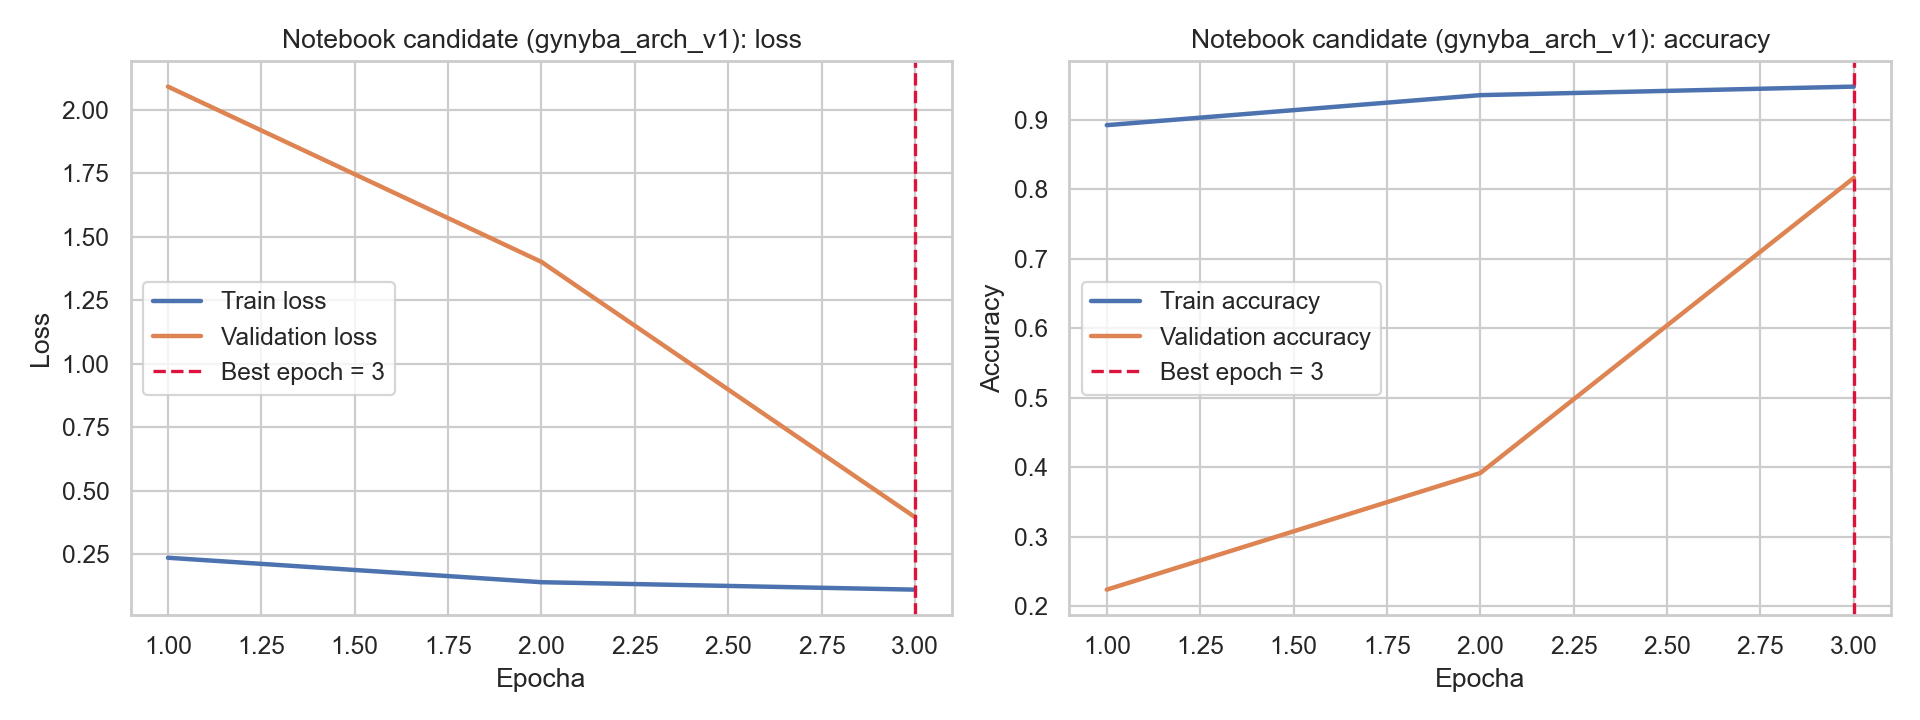

### Confusion matrix

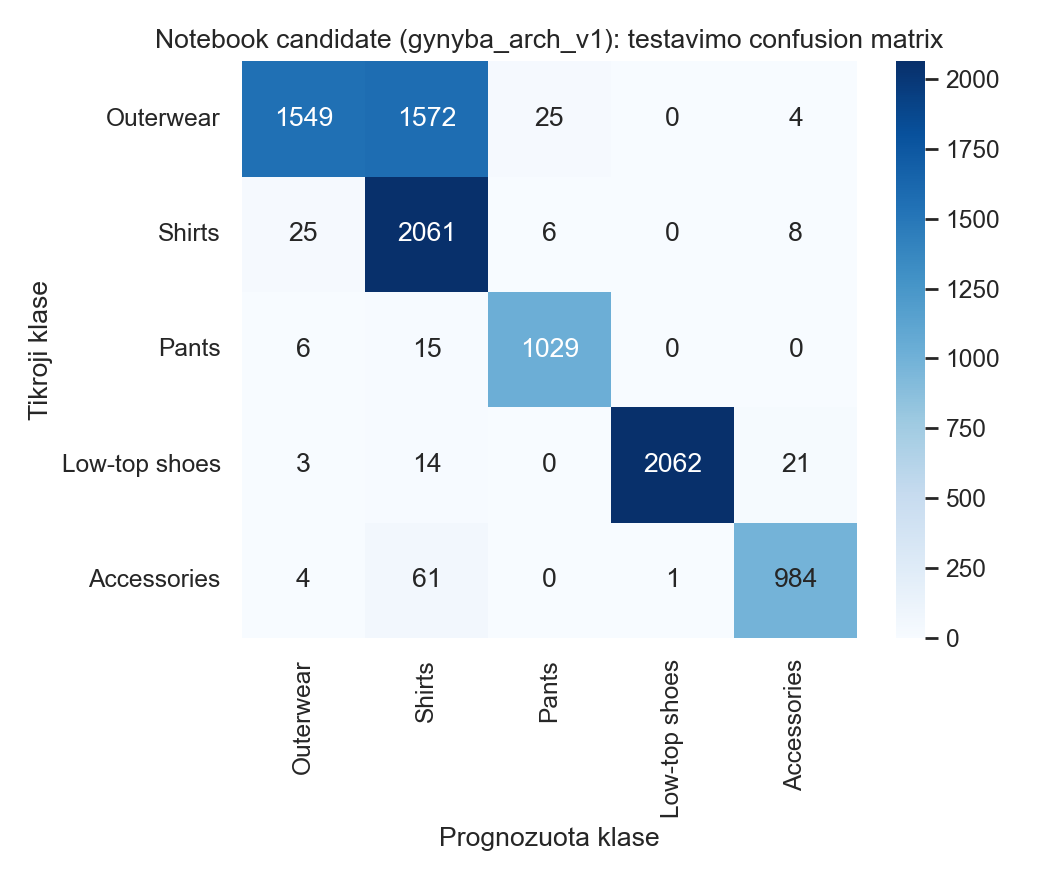

In [9]:
display(Markdown("### Mokymo istorija"))
display(Image(filename=str(PROJECT_ROOT / Path(result["history_plot"]))))

display(Markdown("### Confusion matrix"))
display(Image(filename=str(PROJECT_ROOT / Path(result["confusion_matrix_plot"]))))


In [10]:
report = json.loads((PROJECT_ROOT / Path(result["classification_report_json"])).read_text(encoding="utf-8"))
report_rows = list(CLASS_NAMES.values()) + ["accuracy", "macro avg", "weighted avg"]
report_df = pd.DataFrame(report).T.loc[report_rows]

display(Markdown("### Classification report"))
display(report_df)


### Classification report

,precision,recall,f1-score,support
Outerwear,0.9761,0.4917,0.6540,3150.0000
Shirts,0.5536,0.9814,0.7079,2100.0000
Pants,0.9708,0.9800,0.9754,1050.0000
Low-top shoes,0.9995,0.9819,0.9906,2100.0000
Accessories,0.9676,0.9371,0.9521,1050.0000
accuracy,0.8132,0.8132,0.8132,0.8132
macro avg,0.8935,0.8744,0.8560,9450.0000
weighted avg,0.8859,0.8132,0.8096,9450.0000
